# [실습] Multimodal RAG 구현하기

일반적인 RAG 구조에서, 성능이 떨어지는 대표적인 상황은 이미지/테이블 데이터가 포함된 문서를 처리하는 경우입니다.

일반적인 문서 로더를 이용해 RAG를 수행할 경우, 텍스트만 활용하게 되어 정보의 부분적 손실이 발생하는데요.    

이번 실습에서는 오픈 소스 라이브러리 파서인 Docling을 이용해 이미지/표 등이 포함된 PDF 문서를 재구성하고, 이를 통해 RAG를 수행해 보겠습니다.

## 필수 라이브러리 설치

docling 라이브러리를 설치합니다.    

GITHUB: https://github.com/DS4SD/docling   

https://docling-project.github.io/docling/

In [ ]:
!pip install docling==2.48.0 langchain==0.3.27 langchain_huggingface sentence_transformers jsonlines langchain-openai langchain-google-genai langchain-community==0.3.27 beautifulsoup4 langchain_chroma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 15.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 6.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.3/212.3 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.6/86.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from rich import print as rprint

load_dotenv('env', override=True)

reasoning = {
    "effort": "medium",  # 'low', 'medium', or 'high'
    "summary": "auto",  # 'detailed', 'auto', or None
}

llm = ChatOpenAI(model="gpt-5-mini", reasoning=reasoning)
response = llm.invoke("멀티모달 RAG 알아?")
response

AIMessage(content=[{'type': 'text', 'text': '네, 알아요 — 멀티모달 RAG( Retrieval-Augmented Generation )에 대해 설명해드릴게요.\n\n요약\n- RAG = Retrieval-Augmented Generation: 외부 지식(문서, DB 등)을 검색해 LLM이 생성할 때 근거로 삼게 하는 방식.\n- 멀티모달 RAG는 검색·인덱스·입력·생성 과정에 텍스트뿐 아니라 이미지·오디오·비디오 등 여러 모달리티를 포함하는 RAG를 말합니다.\n\n핵심 구성요소\n1. 데이터 준비: 텍스트, 이미지, 오디오, 비디오를 적절히 전처리(이미지 캡션화, 오디오 텍스트화/특징 추출 등).\n2. 임베딩/인덱싱:\n   - 각 모달에 맞는 임베더로 벡터화(예: 텍스트→SBERT/OpenAI embedding, 이미지→CLIP/ViT 기반 임베딩, 오디오→Wav2Vec 등).\n   - 벡터 DB(FAISS, Milvus, Weaviate, Pinecone 등)에 저장.\n3. 검색기(Retriever):\n   - 쿼리(텍스트/이미지/혼합)를 임베딩으로 변환해 유사도 검색.\n   - 모달별 검색 혹은 통합(공통 임베딩 공간) 검색.\n4. 재랭킹(Reranker, optional):\n   - Dense retriever 결과를 cross-encoder 등으로 정밀 점검해 상위 문서 선별.\n5. 생성기(Generator):\n   - LLM에 검색 결과(텍스트, 캡션, 이미지 임베딩 요약 등)를 컨텍스트로 제공해 답 생성.\n   - 멀티모달 LLM(예: BLIP-2 기반 파이프라인, LLaVA, MiniGPT-4, GPT-4V 등)을 쓰면 이미지도 직접 입력 가능.\n\n구현 전략(대표적)\n- Late fusion (모달별 분리): 텍스트/이미지/오디오 각각 임베딩·검색 → 결과 통합 → LLM로 전달. 구현 쉬움, 모듈화 용이.\n- Early fusion (공통 임베딩 공간): 텍스트·이미지를 같은 벡터

In [ ]:
print(response.text())

네, 알아요 — 멀티모달 RAG( Retrieval-Augmented Generation )에 대해 설명해드릴게요.

요약
- RAG = Retrieval-Augmented Generation: 외부 지식(문서, DB 등)을 검색해 LLM이 생성할 때 근거로 삼게 하는 방식.
- 멀티모달 RAG는 검색·인덱스·입력·생성 과정에 텍스트뿐 아니라 이미지·오디오·비디오 등 여러 모달리티를 포함하는 RAG를 말합니다.

핵심 구성요소
1. 데이터 준비: 텍스트, 이미지, 오디오, 비디오를 적절히 전처리(이미지 캡션화, 오디오 텍스트화/특징 추출 등).
2. 임베딩/인덱싱:
   - 각 모달에 맞는 임베더로 벡터화(예: 텍스트→SBERT/OpenAI embedding, 이미지→CLIP/ViT 기반 임베딩, 오디오→Wav2Vec 등).
   - 벡터 DB(FAISS, Milvus, Weaviate, Pinecone 등)에 저장.
3. 검색기(Retriever):
   - 쿼리(텍스트/이미지/혼합)를 임베딩으로 변환해 유사도 검색.
   - 모달별 검색 혹은 통합(공통 임베딩 공간) 검색.
4. 재랭킹(Reranker, optional):
   - Dense retriever 결과를 cross-encoder 등으로 정밀 점검해 상위 문서 선별.
5. 생성기(Generator):
   - LLM에 검색 결과(텍스트, 캡션, 이미지 임베딩 요약 등)를 컨텍스트로 제공해 답 생성.
   - 멀티모달 LLM(예: BLIP-2 기반 파이프라인, LLaVA, MiniGPT-4, GPT-4V 등)을 쓰면 이미지도 직접 입력 가능.

구현 전략(대표적)
- Late fusion (모달별 분리): 텍스트/이미지/오디오 각각 임베딩·검색 → 결과 통합 → LLM로 전달. 구현 쉬움, 모듈화 용이.
- Early fusion (공통 임베딩 공간): 텍스트·이미지를 같은 벡터 공간에 매핑 → 직접 교차모달 검색. 더 자연스러운 교차모달 매칭 가능하지만 학습/구축이 복잡.
- Hybrid: 텍스

docling은 PDF 데이터를 마크다운으로 변환합니다.      
텍스트 이외에도, 표와 이미지를 바운딩 박스로 추출할 수 있습니다.

In [ ]:
# 기본 코드: Image를 제외한 텍스트를 마크다운으로 변경

from docling.document_converter import DocumentConverter

source = "https://arxiv.org/pdf/2408.09869"  # PDF path or URL
converter = DocumentConverter()
result = converter.convert(source)

with open("result.md", "w") as f:
    f.write(result.document.export_to_markdown())  # output: "### Docling Technical Report[...]"

f.close()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Docling은 다음의 작업을 지원합니다.
1. 각 페이지를 이미지로 추출하기
2. 페이지에 포함된 각 이미지를 추출하기
3. 전체를 HTML/MD 형식으로 재구성하기

In [ ]:
import logging
import time
import re
import requests
from pathlib import Path
from urllib.parse import urlparse
from docling_core.types.doc import ImageRefMode, PictureItem, TableItem
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

IMAGE_RESOLUTION_SCALE = 2.0
# 이미지 해상도 확대 스케일링

_log = logging.getLogger(__name__)

def download_pdf(url, save_dir="downloads"):
    """URL에서 PDF 파일을 다운로드하여 로컬 경로를 반환"""
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    response = requests.get(url, stream=True)
    if response.status_code == 200:
        filename = url.split("/")[-1]

        if not filename.endswith('pdf'):
            filename+='.pdf'
        file_path = save_dir / filename

        with open(file_path, "wb") as f:
            for chunk in response.iter_content(1024):
                f.write(chunk)

        return str(file_path)
    else:
        raise Exception(f"Failed to download file: {url} (Status code: {response.status_code})")

def is_url(path):
    """주어진 문자열이 URL인지 확인"""
    return re.match(r'https?://', path) is not None

def parse(path, output_dir='docling_result',
capture_page_as_images = False,
capture_table_as_images = False,
capture_picture_as_images = False,
parse_with_image_refs = False):

    logging.basicConfig(level=logging.INFO)

    if is_url(path):  # URL이면 다운로드
        _log.info(f"Downloading PDF from {path}...")
        path = download_pdf(path)

    input_doc_path = Path(path)
    output_dir = Path(output_dir)

    pipeline_options = PdfPipelineOptions()
    pipeline_options.images_scale = IMAGE_RESOLUTION_SCALE
    pipeline_options.generate_page_images = True
    pipeline_options.generate_picture_images = True

    doc_converter = DocumentConverter(
        format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)}
    )

    start_time = time.time()
    conv_res = doc_converter.convert(input_doc_path)

    output_dir.mkdir(parents=True, exist_ok=True)
    doc_filename = conv_res.input.file.stem

    # 페이지 이미지 저장
    if capture_page_as_images:
        print("Capturing page images...")
        for page_no, page in conv_res.document.pages.items():
            page_image_filename = output_dir / f"{doc_filename}-{page_no}.png"
            with page_image_filename.open("wb") as fp:
                page.image.pil_image.save(fp, format="PNG")

    # 이미지/테이블 저장
    if capture_table_as_images:
        print("Capturing table images...")
        table_counter = 0
        for element, _level in conv_res.document.iterate_items():
            if isinstance(element, TableItem):
                table_counter += 1
                element_image_filename = output_dir / f"{doc_filename}-table-{table_counter}.png"
                with element_image_filename.open("wb") as fp:
                    element.get_image(conv_res.document).save(fp, "PNG")

    if capture_picture_as_images:
        print("Capturing picture images...")
        picture_counter = 0
        for element, _level in conv_res.document.iterate_items():
            if isinstance(element, PictureItem):
                picture_counter += 1
                element_image_filename = output_dir / f"{doc_filename}-picture-{picture_counter}.png"
                with element_image_filename.open("wb") as fp:
                    element.get_image(conv_res.document).save(fp, "PNG")

    # 전체 마크다운 저장 (이미지는 링크 형태로)
    if parse_with_image_refs:
        print("Saving markdown with image references...")
        md_filename = output_dir / f"{doc_filename}-with-image-refs.md"
        conv_res.document.save_as_markdown(md_filename, image_mode=ImageRefMode.REFERENCED)

    else:
        # 전체 마크다운 저장 (이미지는 utf8 형태로)
        print("Saving markdown with images...")
        md_filename = output_dir / f"{doc_filename}-with-images.md"
        conv_res.document.save_as_markdown(md_filename, image_mode=ImageRefMode.EMBEDDED)


    end_time = time.time() - start_time
    _log.info(f"Document converted and figures exported in {end_time:.2f} seconds.")
    _log.info(f"Output file: {md_filename}")
    # total number of images and tables
    _log.info(f"Total number of tables: {table_counter}")
    _log.info(f"Total number of pictures: {picture_counter}")

# 실행 예시
parse("https://arxiv.org/pdf/2503.09516", capture_page_as_images=True, capture_table_as_images=True, capture_picture_as_images=True, parse_with_image_refs=True)


Capturing page images...
Capturing table images...
Capturing picture images...
Saving markdown with image references...


`with-image-refs.md` 파일에는 이미지 파일의 경로가 마크다운 링크로 포함되어 있습니다.    

이를 이용해, 전체 문서에서 각 이미지를 캡셔닝하고, 이를 바탕으로 멀티모달 RAG를 수행합니다.

In [ ]:
def simple_parse(path, output_dir='mm_rag'):
    logging.basicConfig(level=logging.INFO)

    if is_url(path):  # URL이면 다운로드
        _log.info(f"Downloading PDF from {path}...")
        path = download_pdf(path)

    input_doc_path = Path(path)
    output_dir = Path(output_dir)

    pipeline_options = PdfPipelineOptions()
    pipeline_options.images_scale = IMAGE_RESOLUTION_SCALE
    pipeline_options.generate_page_images = True
    pipeline_options.generate_picture_images = True

    doc_converter = DocumentConverter(
        format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)}
    )

    start_time = time.time()
    conv_res = doc_converter.convert(input_doc_path)

    output_dir.mkdir(parents=True, exist_ok=True)
    doc_filename = conv_res.input.file.stem

    # # 이미지/테이블 저장
    # table_counter = 0
    # picture_counter = 0
    # for element, _level in conv_res.document.iterate_items():
    #     if isinstance(element, TableItem):
    #         table_counter += 1
    #         element_image_filename = output_dir / f"{doc_filename}-table-{table_counter}.png"
    #         with element_image_filename.open("wb") as fp:
    #             element.get_image(conv_res.document).save(fp, "PNG")

    #     if isinstance(element, PictureItem):
    #         picture_counter += 1
    #         element_image_filename = output_dir / f"{doc_filename}-picture-{picture_counter}.png"
    #         with element_image_filename.open("wb") as fp:
    #             element.get_image(conv_res.document).save(fp, "PNG")

    # 전체 마크다운 저장(이미지는 Reference 형태로)
    md_filename = f"{output_dir}/{doc_filename}-with-image-refs.md"
    conv_res.document.save_as_markdown(md_filename, image_mode=ImageRefMode.REFERENCED)

    end_time = time.time() - start_time
    _log.info(f"Document converted and figures exported in {end_time:.2f} seconds.")
    return str(md_filename)



example_path = 'https://arxiv.org/pdf/2503.09516'
md_path = simple_parse(example_path)

마크다운 텍스트를 불러옵니다.

In [ ]:
with open(md_path, "r") as f:
    markdown_text = f.read()

print(markdown_text[1300:2400])


simple outcome-based reward function. Experiments on seven question-answering datasets show that SEARCH-R1 improves performance by 24% (Qwen2.57B) and 20% (Qwen2.5-3B) over various RAG baselines under the same setting. This paper further provides empirical insights into RL optimization methods, LLM choices, and response length dynamics in retrievalaugmented reasoning. The code and model checkpoints are available at https://github.com/PeterGriffinJin/Search-R1 .

## 1 Introduction

Large language models (LLMs) have demonstrated remarkable capabilities in natural language understanding and generation (Hendrycks et al., 2020; Clark et al., 2018). Despite these achievements, LLMs often encounter challenges when tasked with complex reasoning (Wei et al., 2022) and retrieving up-to-date information from external sources (Jin et al., 2024). Addressing these limitations necessitates integrating advanced reasoning abilities (Huang &amp; Chang, 2022) and the capability to interact effectively wi

In [ ]:
import re

# get [Image] ()
image_list = re.findall(r'\[Image\]\((.*?)\)', markdown_text)
len(image_list)
image_list

['mm_rag/2503.09516-with-image-refs_artifacts/image_000000_3435287df52bcf353a2ed9c4a942f82ba35c6331818886b54ff87de7d8e79ae0.png',
 'mm_rag/2503.09516-with-image-refs_artifacts/image_000001_0054989eae7b68fcdede99d6e4f215a5288c0f723cafcca4597530e727b3b1d1.png',
 'mm_rag/2503.09516-with-image-refs_artifacts/image_000002_8aad4f92a45a10b2fe8bf03880d05988b036eeca452fc853dea7ab51b380f5b3.png',
 'mm_rag/2503.09516-with-image-refs_artifacts/image_000003_41136b8e9992fdde6e95c898dcc81dd3eb3390559f0aed39e970e854c0193ad7.png',
 'mm_rag/2503.09516-with-image-refs_artifacts/image_000004_d675ebcadb5e7f2e6c7c1f4f6a630defcb742a283bb4053e58e186bec780d601.png',
 'mm_rag/2503.09516-with-image-refs_artifacts/image_000005_faac88c8dbbe94c944d0e858e5574709880baa1b921549c1de63c69a4828b177.png',
 'mm_rag/2503.09516-with-image-refs_artifacts/image_000006_15f530cd6186179b119176bfb6de8fb3b88cf7de8bc750371a99c3258f4d189e.png',
 'mm_rag/2503.09516-with-image-refs_artifacts/image_000007_a2d98917b4596c673bfb294fa854921

마크다운 텍스트에서, 각각의 이미지는 [Image] (링크) 구조로 만들어집니다.   

해당 패턴을 모두 찾은 뒤, 직전/직후의 N글자 청크를 포함하여 캡션을 생성합니다.

In [ ]:
import re
import requests
from io import BytesIO
from PIL import Image

def extract_image_info(markdown_text, n=500, output_path='mm_rag'):
    """
    마크다운 텍스트에서 이미지 태그 정보를 추출하여 리스트로 반환합니다.

    Args:
        markdown_text (str): 마크다운 텍스트
        n (int): 이미지 태그 직전/직후 글자 수

    Returns:
        list: [직전N글자, 직후N글자, 이미지] 형태의 이중 리스트
    """

    image_pattern = r'!\[.*?\]\((.*?)\)'
    matches = re.finditer(image_pattern, markdown_text)
    image_info_list = []

    for match in matches:
        image_path = match.group(1)
        start_index = match.start()
        end_index = match.end()

        # 직전 N글자 추출
        before_text = markdown_text[max(0, start_index - n):start_index]
        # 직후 N글자 추출
        after_text = markdown_text[end_index:min(len(markdown_text), end_index + n)]


        full_path = f"{output_path}/{image_path}" #base path와 image path합치기

        image_info_list.append([before_text, after_text, full_path])

    return image_info_list


# 이미지 정보 추출 및 출력
image_info = extract_image_info(markdown_text, n=1000)

print('전체 이미지 수:', len(image_info))
for before, after, image in image_info:
    print('----------------------------------------------')

    print(f"{before} \n [Image Goes Here] \n {after}")
    print('----------------------------------------------')

전체 이미지 수: 12
----------------------------------------------
imization (GRPO) (Shao et al., 2024), which eliminates the need for a critic model by estimating baselines from group scores, and RLOO (Ahmadian et al., 2024), which introduces a simplified REINFORCE-style (Williams, 1992) optimization framework. Despite these advances, the application of RL to LLM-driven search engine interactions and reasoning remains largely unexplored.

## 3 Search-R1

In the following sections, we present the detailed design for training methods of SEARCH-R1, covering (1) extending RL to utilize search engines; (2) text generation with an interleaved multi-turn search engine call; (3) the training template; and (4) reward model design.

## 3.1 Reinforcement Learning with a Search Engine

We formulate the RL objective function utilizing a search engine R as follows:

<!-- formula-not-decoded -->

Figure 1: Demonstration of PPO and GRPO training with the search engine (SEARCH-R1). During the rollout, LLMs c

이미지를 정상적으로 추출했고, 앞뒤 캡션을 연결하는 과정을 확인했습니다.    
이제 LLM을 통해 캡션을 생성합니다.

llm에게 전체 문서의 내용을 포함하여, Image의 정보를 얻는 Contextual Retrieval을 수행합니다.

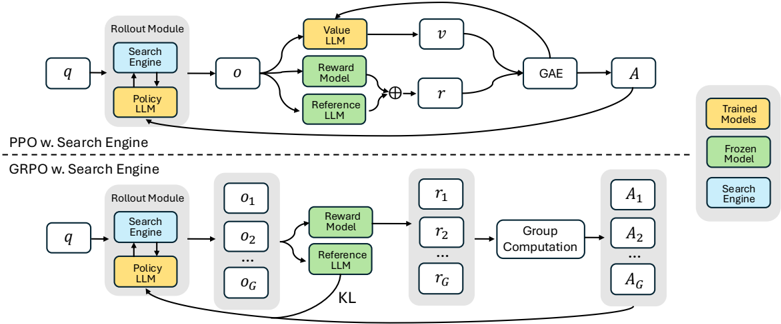

In [ ]:
Image.open(f'mm_rag/{image_list[0]}')

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import base64

def get_caption(before, after, image_path):
    with open(image_path, 'rb') as f:
        image_data = base64.b64encode(f.read()).decode('utf-8')
    context_prompt = ChatPromptTemplate(
        [
            ('system', '''
당신은 주어진 문서의 내용을 참고하여, 이미지에 대한 캡션을 작성해야 합니다.
전체 문서의 전반부 내용과 이미지 이전의 텍스트와 이후의 텍스트가 주어집니다.
이를 활용하여, 문맥을 고려하여 이해를 돕기 위한 캡션을 작성하세요.

캡션의 내용은 최대 5문장으로 작성하고, 원문 Document의 언어를 그대로 따르세요.
만약 문서가 영어인 경우, 영어로 작성하세요.'''),
            ('user',
            [{'type':'text', 'text':'''
[Document]: {document}

---

[Before]: {before}

---

[Image goes Here]

---
[After]: {after}'''},
            {"type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{image_data}"}
                    }
            ]
        )])


    context_chain = context_prompt.partial(document=markdown_text) | llm | StrOutputParser()
    result = context_chain.invoke({'before':before, 'after':after})
    return result

두 함수를 바탕으로, 마크다운 텍스트를 입력으로 받아 캡션을 추가하는 함수를 구현합니다.

In [ ]:
def extract_image_info(markdown_text, n=10, output_path='mm_rag'):
    """
    마크다운 텍스트에서 이미지 태그 정보를 추출하고 캡션을 추가합니다.

    Args:
        markdown_text (str): 마크다운 텍스트
        n (int): 이미지 태그 직전/직후 글자 수
        output_path (str): 이미지 파일의 기본 경로

    Returns:
        str: 캡션이 추가된 마크다운 텍스트
    """

    caption_list = []

    image_pattern = r'!\[.*?\]\((.*?)\)'
    matches = list(re.finditer(image_pattern, markdown_text))


    for match in matches:
        image_path = match.group(1)
        start_index = match.start()
        end_index = match.end()

        # 직전 N글자 추출
        before_text = markdown_text[max(0, start_index - n):start_index]
        # 직후 N글자 추출
        after_text = markdown_text[end_index:min(len(markdown_text), end_index + n)]

        full_path = f"{output_path}/{image_path}" #base path와 image path합치기

        caption = get_caption(before_text, after_text, full_path)
        caption_list.append(caption)
    return caption_list

print(len(markdown_text))

caption_list = extract_image_info(markdown_text,500)
print(len(caption_list))

115826
12


In [ ]:
caption_list

['Figure 1: Illustration of PPO (top) and GRPO (bottom) training with an integrated search engine in SEARCH-R1. The Rollout Module shows the policy LLM interleaving generation and external search calls to produce a rollout observation o (or a group of rollouts o1...oG); in PPO each rollout is evaluated by a frozen Value LLM and a Reward Model to produce value v and reward r, which are combined via GAE to produce advantages A for policy updates. In GRPO the reference LLM and reward model score a group of sampled outputs to produce rewards r1...rG, which are converted with a group computation into relative advantages A1...AG and regularized by a KL term. Legend: trained modules (yellow), frozen models (green), and the search engine (blue).',
 'Training dynamics of SEARCH-R1 across different settings. (a) PPO vs. GRPO: GRPO converges faster but can exhibit instability, while PPO is slower yet more stable. (b) Base vs. Instruct: instruction-tuned models start higher and converge faster, bu

이미지와 텍스트를 포함하는 벡터 DB를 구성하겠습니다.

In [ ]:
from langchain_core.documents import Document

doc = Document(markdown_text, metadata={'type': 'text'})

from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000,
    chunk_overlap=400,
)


chunks = text_splitter.split_documents([doc])
print('Text Chunks:', len(chunks))

images= [Document(page_content = caption, metadata = {'type':'image', 'source': image_list[i]}) for i, caption in enumerate(caption_list)]

print('Image Chunks:', len(images))


Text Chunks: 78
Image Chunks: 12


In [ ]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model = 'text-embedding-3-large', chunk_size=100)

Chroma().delete_collection()

db = Chroma(persist_directory='./chroma_mmrag',
            embedding_function=embeddings,
            collection_metadata={'hnsw:space':'l2'}
            )

db.add_documents(images)
db.add_documents(chunks)

retriever = db.as_retriever(search_kwargs={"k": 5})

RAG 체인을 구성합니다.   
원문 문서가 영어로 되어 있으므로, 번역 체인을 추가합니다.

In [ ]:
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser
from langchain.prompts import ChatPromptTemplate


In [ ]:
translate_prompt = ChatPromptTemplate([
    ("system", """You are a helpful assistant that translates Korean Question to English.
Translate the following question to English.
Just Write the translated Question and nothing else"""),
    ("user", "Korean Question:{text}")
])

translate_chain = translate_prompt | llm | StrOutputParser()

translate_chain.invoke("왜 논문 이름이 Search-R1이야?")

'Why is the paper titled Search-R1?'

In [ ]:
prompt = ChatPromptTemplate([
    ("user", '''당신은 QA(Question-Answering)을 수행하는 Assistant입니다.
다음의 Context를 이용하여 Question에 한국어로 답변하세요.
정확한 답변을 제공하세요.
만약 모든 Context를 다 확인해도 정보가 없다면, "정보가 부족하여 답변할 수 없습니다."를 출력하세요.
---
Context: {context}
---
Question: {question}''')])

prompt.pretty_print()

================================ Human Message =================================

당신은 QA(Question-Answering)을 수행하는 Assistant입니다.
다음의 Context를 이용하여 Question에 한국어로 답변하세요.
정확한 답변을 제공하세요.
만약 모든 Context를 다 확인해도 정보가 없다면, "정보가 부족하여 답변할 수 없습니다."를 출력하세요.
---
Context: {context}
---
Question: {question}


In [ ]:
def format_docs(docs):
    return "\n\n---\n\n".join(['Content:' +doc.page_content for doc in docs])
    # join : 구분자를 기준으로 스트링 리스트를 하나의 스트링으로 연결

rag_chain = (
    {"context": translate_chain | retriever | format_docs, "question": RunnablePassthrough()}
    # retriever : question을 받아서 context 검색: document 반환
    # format_docs : document 형태를 받아서 텍스트로 변환
    # RunnablePassthrough(): 체인의 입력을 그대로 저장
    | prompt
    | llm
    | StrOutputParser()
)

In [ ]:
rag_chain.invoke("왜 논문 이름이 Search-R1이야? DeepSeek 모델이야?")

'간단히 정리하면:\n\n- 이름 유래: SEARCH-R1은 "SEARCH" (검색 기반 상호작용)와 "R1"을 결합한 이름입니다. 논문 자체에서 SEARCH-R1을 검색(검색엔진을 활용한)으로 강화한 R1 스타일의 강화학습(framework)로 소개하며, 검색을 통합한 R1 계열의 확장판이라는 의미로 명명되었습니다.\n- 딥시크(DeepSeek) 모델과의 관계: SEARCH-R1은 딥시크 계열의 완전한 동일모델은 아니고, DeepSeek-R1 Zero(Guo et al., 2025)를 확장한 방식입니다. 즉, DeepSeek-R1 Zero가 주로 파라메트릭(모델 내부) 추론에 초점을 둔 것이라면, SEARCH-R1은 거기에 검색엔진을 환경으로 포함시켜 다중 턴 검색·추론, 검색 토큰 마스킹, 결과기반 보상 등 검색-증강 RL 훈련을 추가한 확장판입니다.\n\n원문에서는 SEARCH-R1을 “DeepSeek-R1 Zero 스타일의 RL을 검색으로 확장한 것”이라고 명시하고 있으므로, 완전히 다른 모델이라기보다 딥시크 R1 계열의 검색-증강 확장으로 이해하시면 됩니다.'

In [ ]:
rag_chain_v2 = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}

    | RunnablePassthrough().assign(answer = prompt | llm | StrOutputParser())
)

In [ ]:
rag_chain_v2.invoke("검색 과정에 RL을 어떻게 적용해?")

{'context': 'Content:approaches offer greater adaptability but are difficult to scale effectively due to their reliance on large-scale, high-quality annotated trajectories and the inherent non-differentiability of the search operation, which renders end-to-end gradient descent-based optimization inapplicable (Schick et al., 2023; Asai et al., 2024).\n\nReinforcement Learning (RL) (Sutton et al., 1999; Kaelbling et al., 1996) has emerged as a potent paradigm for enhancing the reasoning capabilities of LLMs (Guo et al., 2025; Hou et al., 2025; Xie et al., 2025; Kumar et al., 2024). Notably, models like OpenAI-o1 (Jaech et al., 2024) and DeepSeek-R1 (Guo et al., 2025) have leveraged RL techniques ( e.g. , PPO (Schulman et al., 2017) and GRPO (Shao et al., 2024)) to improve logical inference and problem-solving skills by learning from experience and feedback. With RL, even when trained solely on the outcome rewards, the models learn complex reasoning capabilities, including selfverificatio

Retriever의 결과를 확인하여 질문이 주어지면 관련 이미지의 링크를 함께 전달하게 만들어 보겠습니다.   
해당 링크를 화면에 띄우는 방식으로, 답변과 함께 보여주는 것도 가능할 것 같습니다.

In [ ]:
retriever = db.as_retriever(search_kwargs={"k": 10})

In [ ]:
def format_docs(docs):
    return "\n\n---\n\n".join(['Content:' +doc.page_content for doc in docs])
    # join : 구분자를 기준으로 스트링 리스트를 하나의 스트링으로 연결

rag_chain = (
    {"context": translate_chain | retriever | format_docs, "question": RunnablePassthrough()}
    # retriever : question을 받아서 context 검색: document 반환
    # format_docs : document 형태를 받아서 텍스트로 변환
    # RunnablePassthrough(): 체인의 입력을 그대로 저장
    | prompt
    | llm
    | StrOutputParser()
)

--- 이미지 1 ---
캡션: Figure 1: Illustration of PPO (top) and GRPO (bottom) training with an integrated search engine in SEARCH-R1. The Rollout Module shows the policy LLM interleaving generation and external search calls to produce a rollout observation o (or a group of rollouts o1...oG); in PPO each rollout is evaluated by a frozen Value LLM and a Reward Model to produce value v and reward r, which are combined via GAE to produce advantages A for policy updates. In GRPO the reference LLM and reward model score a group of sampled outputs to produce rewards r1...rG, which are converted with a group computation into relative advantages A1...AG and regularized by a KL term. Legend: trained modules (yellow), frozen models (green), and the search engine (blue).


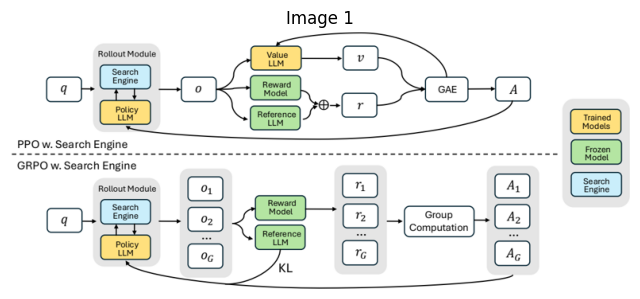

In [ ]:
from typing import List
from langchain_core.documents import Document
from PIL import Image
import matplotlib.pyplot as plt
import os

def show_images_with_caption(docs: List[Document]):
    """
    랭체인 Document 객체 목록에서 이미지와 해당 캡션을 순서대로 화면에 표시합니다.
    Document의 metadata['type']이 'image'인 경우에만 처리합니다.

    각 Document 객체는 다음을 포함해야 합니다:
    - metadata['source']: 이미지 파일의 경로 (문자열).
    - metadata['type']: 문서의 타입 (예: 'image', 'text' 등).
    - page_content: 이미지에 대한 캡션 (문자열).

    Args:
        docs: 랭체인 Document 객체의 목록.
    """
    if not docs:
        print("표시할 문서가 없습니다.")
        return

    image_count = 0
    for i, doc in enumerate(docs):
        # 문서 타입이 'image'인지 확인
        if doc.metadata.get('type') != 'image':
            # print(f"--- 문서 {i+1} (건너뜀) ---")
            # print(f"이 문서는 이미지가 아닙니다 (type: {doc.metadata.get('type', 'N/A')}).")
            # print("\n")
            continue

        image_count += 1
        image_path = 'mm_rag/'+ doc.metadata.get('source')
        caption = doc.page_content

        print(f"--- 이미지 {image_count} ---")
        print(f"캡션: {caption}")

        if image_path:
            if os.path.exists(image_path):
                try:
                    img = Image.open(image_path)

                    # Matplotlib을 사용하여 이미지 표시
                    plt.figure(figsize=(8, 6)) # 이미지 표시를 위한 그림 크기 설정
                    plt.imshow(img)
                    plt.axis('off') # 축 숨기기
                    plt.title(f"Image {image_count}")
                    plt.show() # 이미지를 화면에 표시
                except Exception as e:
                    print(f"오류: '{image_path}' 경로의 이미지를 표시할 수 없습니다. 오류: {e}")
            else:
                print(f"오류: 이미지 파일이 존재하지 않습니다: '{image_path}'")
        else:
            print("오류: Document 메타데이터에 'source' (이미지 경로)가 없습니다.")
        print("\n") # 각 이미지와 캡션 사이에 공백 추가

    if image_count == 0:
        print("표시할 이미지가 없습니다.")

docs = retriever.invoke(translate_chain.invoke("검색 과정에 RL을 어떻게 적용해?"))

show_images_with_caption(docs)

In [ ]:
result = rag_chain.invoke("검색 과정에 RL을 어떻게 적용해?")
print(result)
show_images_with_caption(retriever.invoke("question"))

요약하면 SEARCH-R1은 검색 엔진을 RL 환경의 일부로 취급하여 LLM이 생성(추론)과 검색을 교차로 수행하는 일련의 궤적(rollout)을 통해 정책을 학습합니다. 적용 방식의 핵심은 다음과 같습니다.

- 검색 엔진을 환경으로 모델링: 정책 πθ는 외부 검색 R과의 교차(interleaved) 상호작용을 수행하는 πθ(·|x; R) 형태로 취급(πθ(·|x) ⊗ R). 즉 토큰 생성 중에 검색 호출을 삽입해 궤적을 샘플링한다.
- 다중 턴(인터리브드) 검색·추론: 검색 호출은 명시적 토큰(예: <search>…</search>)으로 트리거되고, 검색으로 얻은 내용은 <information>…</information>로 감싸며 LLM의 사고 단계는 <think>…</think>, 최종답은 <answer>…</answer>로 구조화한다. 이를 통해 반복적이고 동적인 검색 전략을 학습할 수 있다.
- 검색 결과(복원된 토큰)는 최적화에서 제외(로스 마스킹): 롤아웃 시 생성된 토큰과 검색으로 들어온 토큰이 섞이므로, retrieved token에 대해 손실을 마스킹(I(yt)=0)하여 정책 그레이디언트가 오직 LLM이 생성한 토큰만 계산되게 함으로써 학습 안정성 확보.
- RL 알고리즘 적용: 기본적으로 PPO를 사용하되(클리핑 항 등 포함), GRPO도 지원하여 그룹 상대적 이점을 이용한 업데이트를 할 수 있음(critic 불필요). PPO 쪽은 가치함수와 GAE로 어드밴티지를 계산하고 업데이트함.
- 보상 설계: 복잡한 프로세스 보상이 아닌 단순한 outcome-based 보상(결과 기반 보상)을 채택. 보상은 보상모델/가치모델로 계산되어 어드밴티지 산출에 사용됨. 실험에서는 이 간단한 보상만으로도 유효함을 보였음.
- 기타 안정화·설계 요소: 레퍼런스 정책(π_ref)과의 KL 정규화, 그룹 기반 보상 처리(GRPO) 등으로 학습을 안정화하고 검색-증강 추론의 성능을 개선함.

한 문장 요약: SEARCH-R1은 검색을 환경의 일부로 포함하고, 검색 